# 05 — Classification Visualization

This notebook visualizes the existing land-cover classification raster and checks that the map is interpreted with its geospatial metadata. It is intended for the project’s existing output, not to retrain a classifier or regenerate the map.

**Read-only workflow:** input rasters and reports are not edited or overwritten. The notebook tries the baseline classification first and then an Extra Trees output if the baseline is unavailable.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.plot import plotting_extent

CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent]
ROOT = next((p for p in CANDIDATE_ROOTS if (p / "outputs").exists() and (p / "data").exists()), Path.cwd())
CLASS_DIR = ROOT / "outputs" / "classification"
FIGURE_DIR = ROOT / "outputs" / "figures"
REPORT_DIR = ROOT / "outputs" / "reports"

print("Repository root:", ROOT)
print("Classification directory exists:", CLASS_DIR.exists())
print("Figures directory exists:", FIGURE_DIR.exists())

Repository root: c:\Users\lenovo\Desktop\satellite-land-cover-classification
Classification directory exists: True
Figures directory exists: True


## 1. Select an existing classification raster

The baseline raster is preferred for consistency with the project’s existing final map/report. The Extra Trees raster is used only if the baseline file is missing. The chosen path is printed so the plotted result is traceable.

In [2]:
raster_candidates = [
    CLASS_DIR / "land_cover_baseline.tif",
    CLASS_DIR / "land_cover_extra_trees.tif",
]
CLASS_RASTER = next((p for p in raster_candidates if p.exists()), None)

if CLASS_RASTER is None:
    available = sorted(CLASS_DIR.glob("*.tif")) if CLASS_DIR.exists() else []
    if available:
        CLASS_RASTER = available[0]
        print("Using first available classification raster:", CLASS_RASTER)
    else:
        raise FileNotFoundError(
            "No classification raster found under outputs/classification/. "
            "Check that the classification output exists."
        )
else:
    print("Selected classification raster:", CLASS_RASTER)

Selected classification raster: c:\Users\lenovo\Desktop\satellite-land-cover-classification\outputs\classification\land_cover_baseline.tif


## 2. Inspect raster metadata and class values

Class IDs are categorical labels, not continuous measurements. Nodata must be excluded from the class counts and displayed transparently. The class-name mapping below follows the project’s documented IDs; verify it against the training labels if the class encoding changes.

In [3]:
CLASS_NAMES = {
    1: "Vegetation",
    2: "Built-up",
    3: "Bare soil",
    4: "Water",
    5: "Road",
}

with rasterio.open(CLASS_RASTER) as src:
    classification = src.read(1, masked=True)
    raster_crs = src.crs
    raster_transform = src.transform
    raster_bounds = src.bounds
    raster_res = src.res
    raster_nodata = src.nodata
    raster_width, raster_height = src.width, src.height
    raster_extent = plotting_extent(src)

print("CRS:", raster_crs)
print("Dimensions (width × height):", raster_width, "×", raster_height)
print("Resolution:", raster_res)
print("Bounds:", raster_bounds)
print("Nodata value:", raster_nodata)
print("Masked pixels:", int(np.ma.getmaskarray(classification).sum()))

valid = classification.compressed()
if valid.size == 0:
    raise ValueError("The selected raster contains no unmasked pixels.")
unique_values, counts = np.unique(valid.astype(np.int64), return_counts=True)
count_table = pd.DataFrame({"class_id": unique_values, "pixel_count": counts})
count_table["class_name"] = count_table["class_id"].map(CLASS_NAMES).fillna("Unknown class ID")
count_table["area_km2_at_10m"] = count_table["pixel_count"] * (abs(raster_res[0] * raster_res[1])) / 1_000_000
display(count_table)

CRS: EPSG:32642
Dimensions (width × height): 528 × 280
Resolution: (10.0, 10.0)
Bounds: BoundingBox(left=864240.0, bottom=2565250.0, right=869520.0, top=2568050.0)
Nodata value: 0.0
Masked pixels: 9463


,class_id,pixel_count,class_name,area_km2_at_10m
0,1,83751,Vegetation,8.3751
1,2,14656,Built-up,1.4656
2,3,27500,Bare soil,2.7500
3,4,1635,Water,0.1635
4,5,10835,Road,1.0835


## 3. Plot the categorical classification map

The display uses discrete class colors and a legend. If the raster has a different pixel size from 10 m, the approximate area column above still uses the raster’s actual pixel dimensions; it should not be described as an exact ground-area estimate if the CRS is geographic or otherwise unsuitable for area calculations.

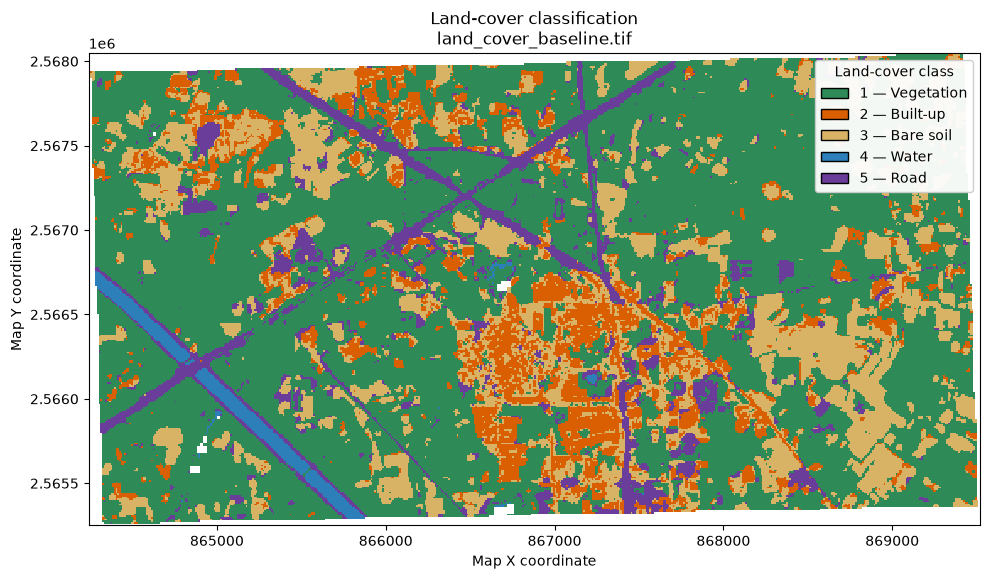

In [4]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Fixed colors are only for consistent categorical display, not a claim about class quality.
color_by_id = {
    1: "#2E8B57",  # vegetation
    2: "#D95F02",  # built-up
    3: "#D8B365",  # bare soil
    4: "#2C7FB8",  # water
    5: "#6A3D9A",  # road
}
class_ids = sorted(CLASS_NAMES)
colors = [color_by_id[c] for c in class_ids]
cmap = ListedColormap(colors)
cmap.set_bad((1, 1, 1, 0))
norm = BoundaryNorm([min(class_ids)-0.5] + [c+0.5 for c in class_ids], cmap.N)

fig, ax = plt.subplots(figsize=(10, 7))
shown = np.ma.masked_where(np.ma.getmaskarray(classification), classification)
im = ax.imshow(shown, cmap=cmap, norm=norm, extent=raster_extent, interpolation="nearest")
legend_items = [
    Patch(facecolor=color_by_id[c], edgecolor="black", label=f"{c} — {CLASS_NAMES[c]}")
    for c in class_ids if np.any(valid == c)
]
ax.legend(handles=legend_items, title="Land-cover class", loc="best", framealpha=0.95)
ax.set_title(f"Land-cover classification\n{CLASS_RASTER.name}")
ax.set_xlabel("Map X coordinate")
ax.set_ylabel("Map Y coordinate")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 4. Class composition

This plot shows the distribution of valid pixels in the selected prediction raster. It describes mapped composition only; it does not validate whether those pixels are correctly classified.

,class_id,pixel_count,class_name,area_km2_at_10m,percent_of_valid_pixels
0,1,83751,Vegetation,8.3751,60.523786
2,3,27500,Bare soil,2.7500,19.873245
1,2,14656,Built-up,1.4656,10.591355
4,5,10835,Road,1.0835,7.830058
3,4,1635,Water,0.1635,1.181555


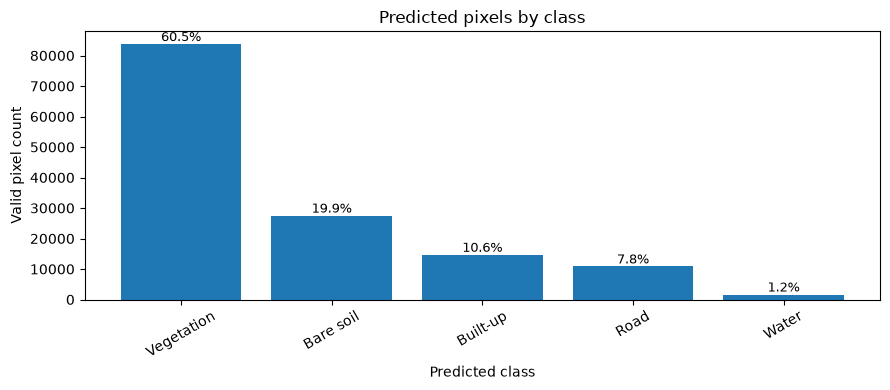

In [5]:
count_table["percent_of_valid_pixels"] = 100 * count_table["pixel_count"] / count_table["pixel_count"].sum()
display(count_table.sort_values("pixel_count", ascending=False))

fig, ax = plt.subplots(figsize=(9, 4))
ordered = count_table.sort_values("pixel_count", ascending=False)
ax.bar(ordered["class_name"], ordered["pixel_count"])
ax.set_title("Predicted pixels by class")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Valid pixel count")
ax.tick_params(axis="x", rotation=30)
for i, row in enumerate(ordered.itertuples()):
    ax.text(i, row.pixel_count, f"{row.percent_of_valid_pixels:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Compare against available map-comparison report

If `classification_map_comparison.csv` exists, show it for context. A difference between classifiers can reveal sensitivity to model choice, but class area differences alone cannot establish which map is more accurate.

In [6]:
comparison_path = REPORT_DIR / "classification_map_comparison.csv"
if comparison_path.exists():
    map_comparison = pd.read_csv(comparison_path)
    display(map_comparison)
else:
    print("No classification_map_comparison.csv found; skipping comparison table.")

,class_id,class_name,random_forest_pixels,extra_trees_pixels,difference_pixels
0,1,vegetation,83751,80946,-2805
1,2,built_up,14656,26633,11977
2,3,bare_soil,27500,20600,-6900
3,4,water,1635,1561,-74
4,5,road,10835,8637,-2198


## 6. Interpretation and limitations

- Class IDs are categorical. Do not apply continuous color ramps or interpret numeric class IDs as quantities.
- Always check CRS, pixel size, bounds, nodata handling, and class mapping before making a final map.
- A predicted class-area chart is not an accuracy assessment.
- Visual plausibility is useful for quality control but does not replace independent validation labels.
- The project’s small, spatially clustered training set and uneven spatial distribution of some classes limit confidence in generalization.
- For publication or submission, include the input acquisition date, AOI, CRS, class definitions, model/predictor details, and validation method.

**No raster, map, or report is overwritten by this notebook.**